# **6. Baseline Modeling: XGBoost**

### **Environment Setup**

This notebook develops and evaluates a baseline Extreme Gradient Boosting (XGBoost) classifier for predicting ten-year coronary heart disease using the Framingham dataset. The modelling environment is configured by importing the required libraries and loading the prepared training and testing datasets for model development and evaluation.

### **Library Imports**

The required libraries are imported to support data manipulation, model development, and performance evaluation.

In [2]:
# Import required libraries

import pandas as pd                  # Data manipulation and analysis
import numpy as np                   # Numerical computations
import matplotlib.pyplot as plt      # Data visualization
import seaborn as sns                # Statistical data visualization
import joblib                        # Saving and loading trained models

# Import the XGBoost classifier
import xgboost as xgb                # Extreme Gradient Boosting classifier

# Import evaluation metrics for model performance assessment
from sklearn.metrics import (
    accuracy_score,                  # Overall prediction accuracy
    precision_score,                 # Proportion of correctly predicted positive cases
    recall_score,                    # Ability to identify actual positive cases
    f1_score,                        # Harmonic mean of precision and recall
    roc_auc_score,                   # Area Under the ROC Curve (AUC)
    classification_report,           # Comprehensive classification performance summary
    confusion_matrix,                # Confusion matrix for prediction outcomes
    roc_curve                        # Receiver Operating Characteristic (ROC) curve
)

### **Data Ingestion**

The previously prepared training and testing datasets are loaded for XGBoost model development. Since XGBoost is a tree-based algorithm, feature standardization is not required, and the unscaled datasets are used directly.

In [3]:
# Load the unscaled training and testing datasets
X_train = pd.read_csv("../data/processed/X_train.csv")
X_test = pd.read_csv("../data/processed/X_test.csv")
y_train = pd.read_csv("../data/processed/y_train.csv").squeeze()
y_test = pd.read_csv("../data/processed/y_test.csv").squeeze()

# Display dataset dimensions
print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)

X_train shape: (3392, 15)
X_test shape : (848, 15)
y_train shape: (3392,)
y_test shape : (848,)


The prepared training and testing datasets were successfully loaded. The unscaled predictor variables were retained because XGBoost is not affected by differences in feature scales.

### **Model Training**

The XGBoost classifier is trained using the unscaled training dataset. A fixed random state is specified to ensure reproducibility, while the default model parameters are used to establish the baseline model.

In [5]:
# Initialize the XGBoost classifier
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    random_state=42,
    eval_metric="logloss"
)

# Train the model
xgb_model.fit(X_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


The XGBoost classifier was successfully trained using the unscaled training dataset and is ready to generate predictions on the testing data.

### **Model Prediction**

The trained XGBoost model is applied to the testing dataset to generate predicted class labels and their corresponding probabilities. These predictions are subsequently used to evaluate the model's classification performance.

In [6]:
# Generate predicted class labels
y_pred = xgb_model.predict(X_test)

# Generate predicted probabilities for the positive class
y_pred_proba = xgb_model.predict_proba(X_test)[:, 1]

print("Predictions generated successfully.")

Predictions generated successfully.


The XGBoost model successfully generated predicted class labels and class probabilities for the testing dataset. These outputs are used to assess the model's predictive performance using multiple evaluation metrics and visualizations.

### **Model Performance Evaluation**

The performance of the XGBoost model is evaluated using several classification metrics, including accuracy, precision, recall, F1-score, and the Area Under the Receiver Operating Characteristic Curve (ROC-AUC). These metrics provide a comprehensive assessment of the model's predictive performance on the unseen testing dataset.

In [7]:
# Calculate the evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

# Create a summary table
evaluation_metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "ROC-AUC"
    ],
    "Value": [
        round(accuracy, 3),
        round(precision, 3),
        round(recall, 3),
        round(f1, 3),
        round(roc_auc, 3)
    ]
})

evaluation_metrics

,Metric,Value
0,Accuracy,0.822
1,Precision,0.250
2,Recall,0.085
3,F1-score,0.127
4,ROC-AUC,0.605


The baseline XGBoost model achieved an accuracy of 82.2% and an ROC-AUC score of 0.605, indicating a modest ability to distinguish between participants who developed coronary heart disease and those who did not. The model achieved a precision of 0.250 but a recall of only 0.085 for the positive class, indicating that only a small proportion of participants who developed coronary heart disease were correctly identified. Although the model maintained reasonable overall accuracy, its relatively low ROC-AUC score and limited recall suggest weaker discriminative performance than the baseline Logistic Regression and Random Forest models. These findings indicate that the baseline XGBoost model is also affected by the class imbalance present in the dataset and has limited sensitivity in detecting positive cases.

### **Confusion Matrix**

The confusion matrix summarizes the classification outcomes by comparing the predicted class labels with the actual class labels. It provides insight into the numbers of true positives, true negatives, false positives, and false negatives produced by the XGBoost model.

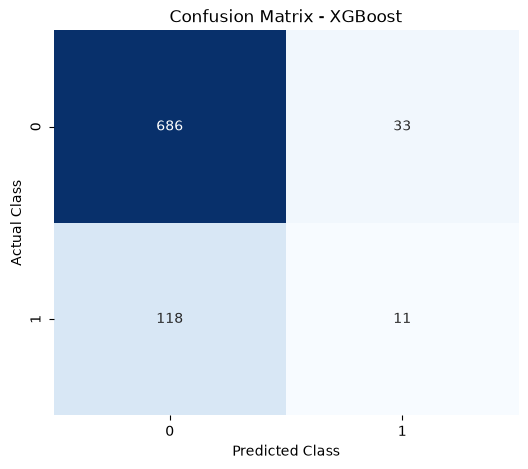

In [8]:
# Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Visualize the confusion matrix
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False
)

# Customize the plot
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Confusion Matrix - XGBoost")

# Display the plot
plt.show()

The confusion matrix shows that the XGBoost model correctly classified 686 participants who did not develop coronary heart disease and 11 participants who developed the disease. However, the model misclassified 118 positive cases as negative, resulting in a large number of false negatives. This finding explains the low recall observed for the positive class and indicates that the baseline XGBoost model is biased towards predicting the majority class. Although the model performs reasonably well in identifying negative cases, its ability to detect participants at risk of developing coronary heart disease remains limited.

### **Classification Report**

The classification report provides a detailed summary of the XGBoost model's performance for each class by presenting precision, recall, F1-score, and support. These metrics offer a more comprehensive evaluation of the classifier, particularly when dealing with imbalanced datasets.

In [9]:
# Display the classification report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.95      0.90       719
           1       0.25      0.09      0.13       129

    accuracy                           0.82       848
   macro avg       0.55      0.52      0.51       848
weighted avg       0.76      0.82      0.78       848



The classification report indicates that the XGBoost model performs substantially better on the majority class than on the minority class. For participants who did not develop coronary heart disease, the model achieved high precision, recall, and F1-score, demonstrating strong predictive performance. In contrast, the positive class exhibited low precision, recall, and F1-score, indicating that only a small proportion of participants who developed coronary heart disease were correctly identified. These findings further confirm that the baseline XGBoost model is affected by the class imbalance present in the dataset and has limited ability to detect minority class instances.

 Calculate scale_pos_weight and train balanced XGBoost

In [7]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print('scale_pos_weight:', scale_pos_weight)

xgb_balanced = xgb.XGBClassifier(
    n_estimators=100,
    random_state=42,
    eval_metric='logloss',
    scale_pos_weight=scale_pos_weight
)
xgb_balanced.fit(X_train, y_train)

y_pred_bal = xgb_balanced.predict(X_test)
y_pred_proba_bal = xgb_balanced.predict_proba(X_test)[:, 1]

print('Accuracy:', accuracy_score(y_test, y_pred_bal))
print('Precision:', precision_score(y_test, y_pred_bal))
print('Recall:', recall_score(y_test, y_pred_bal))
print('F1 Score:', f1_score(y_test, y_pred_bal))
print('ROC-AUC:', roc_auc_score(y_test, y_pred_proba_bal))

scale_pos_weight: 5.586407766990291
Accuracy: 0.7688679245283019
Precision: 0.1926605504587156
Recall: 0.16279069767441862
F1 Score: 0.17647058823529413
ROC-AUC: 0.5680909100710505


Confusion matrix (balanced)

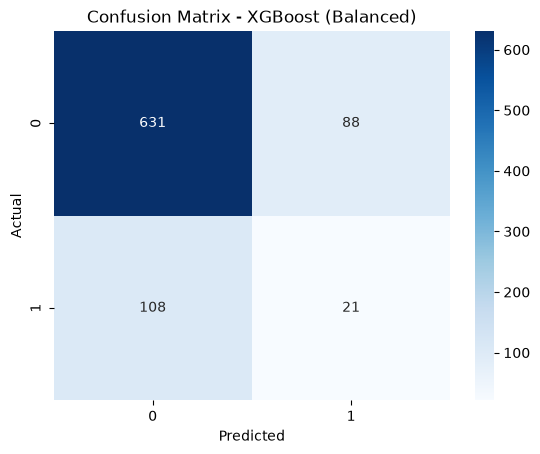

In [8]:
cm = confusion_matrix(y_test, y_pred_bal)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - XGBoost (Balanced)')
plt.show()

classification report balanced

In [9]:
print(classification_report(y_test, y_pred_bal))

              precision    recall  f1-score   support

           0       0.85      0.88      0.87       719
           1       0.19      0.16      0.18       129

    accuracy                           0.77       848
   macro avg       0.52      0.52      0.52       848
weighted avg       0.75      0.77      0.76       848



### **Receiver Operating Characteristic (ROC) Curve**

The Receiver Operating Characteristic (ROC) curve illustrates the trade-off between the true positive rate (sensitivity) and the false positive rate (1 − specificity) across different classification thresholds. The Area Under the Curve (ROC-AUC) provides an overall measure of the model's ability to distinguish between participants who developed coronary heart disease and those who did not.

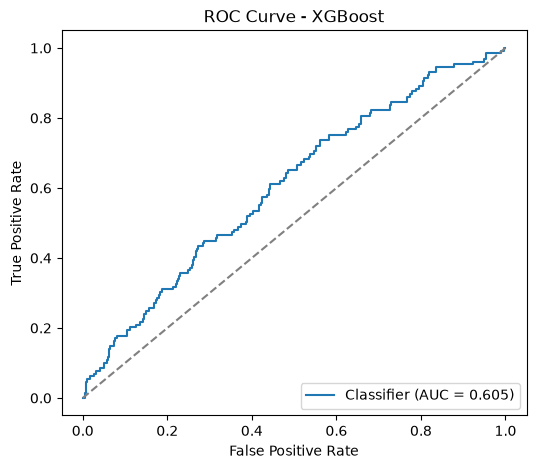

In [10]:
# Compute the ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

# Plot the ROC curve
plt.figure(figsize=(6, 5))

plt.plot(
    fpr,
    tpr,
    label=f"Classifier (AUC = {roc_auc:.3f})"
)

# Plot the reference line
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")

# Customize the plot
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - XGBoost")
plt.legend(loc="lower right")

# Display the plot
plt.show()

The ROC curve demonstrates the discriminative ability of the XGBoost model across different classification thresholds. The model achieved an ROC-AUC score of 0.605, indicating a modest ability to distinguish between participants who developed coronary heart disease and those who did not. Although the model correctly classified most negative cases, its low recall indicates that many positive cases were missed when using the default classification threshold. Consequently, although the baseline XGBoost model provides a useful benchmark, its predictive performance is limited and is expected to improve through hyperparameter tuning and class imbalance handling techniques, which will be investigated in subsequent stages of this study.

### **Feature Importance**

XGBoost estimates the relative importance of predictor variables based on their contribution to improving the model during the boosting process. Examining feature importance provides insight into the variables that most strongly influence the model's predictions.

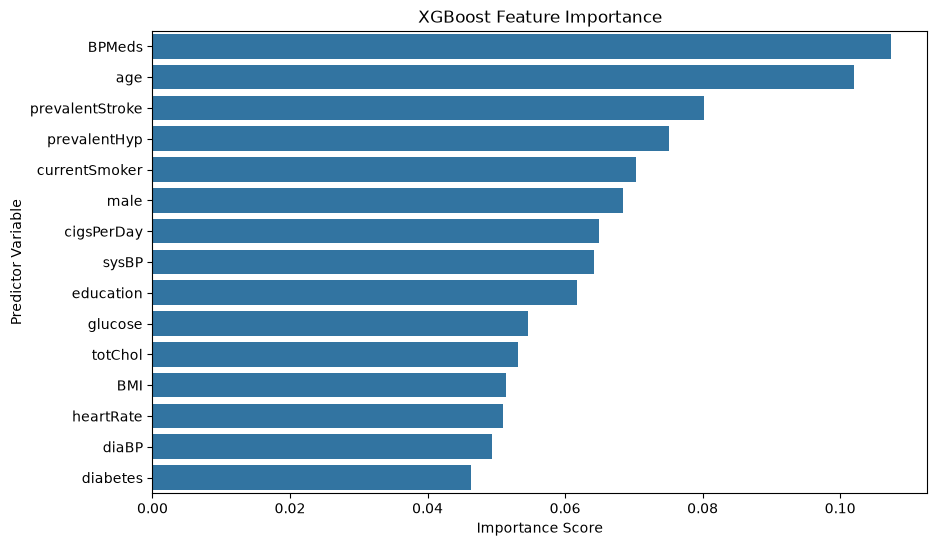

BPMeds             0.107332
age                0.101993
prevalentStroke    0.080141
prevalentHyp       0.075047
currentSmoker      0.070252
male               0.068481
cigsPerDay         0.064908
sysBP              0.064191
education          0.061741
glucose            0.054663
totChol            0.053132
BMI                0.051430
heartRate          0.051040
diaBP              0.049356
diabetes           0.046293
dtype: float32

In [11]:
# Extract feature importance scores from the trained XGBoost model
feature_importance = pd.Series(
    xgb_model.feature_importances_,
    index=X_train.columns
)

# Sort the features from most important to least important
feature_importance = feature_importance.sort_values(ascending=False)

# Plot the feature importance scores
plt.figure(figsize=(10, 6))

sns.barplot(
    x=feature_importance.values,
    y=feature_importance.index
)

# Customize the plot
plt.xlabel("Importance Score")
plt.ylabel("Predictor Variable")
plt.title("XGBoost Feature Importance")

# Display the plot
plt.show()

# Display the numerical importance scores
feature_importance

The feature importance analysis indicates that blood pressure medication use (`BPMeds`) was the most influential predictor of ten-year coronary heart disease in the baseline XGBoost model, followed by age, prevalent stroke, prevalent hypertension, current smoking, and sex (`male`). Variables such as diabetes, diastolic blood pressure (`diaBP`), heart rate, body mass index (`BMI`), and total cholesterol (`totChol`) contributed relatively less to the model's predictions. Unlike the Random Forest model, XGBoost assigned greater importance to several categorical clinical risk factors, reflecting the different way gradient boosting algorithms learn complex relationships within the data. Overall, the feature importance ranking provides insight into the variables that contributed most to the XGBoost model's prediction of coronary heart disease.

### **Model Persistence**

The trained XGBoost model is saved for future use in model comparison, further evaluation, and deployment. Saving the fitted model eliminates the need to retrain it whenever predictions or additional analyses are required.

In [12]:
# Save the trained XGBoost model
joblib.dump(
    xgb_model,
    "../models/xgboost_model.pkl"
)

print("XGBoost model saved successfully.")

XGBoost model saved successfully.


### **Conclusion**

This notebook developed and evaluated a baseline XGBoost model for predicting ten-year coronary heart disease using the Framingham dataset. The model was trained using the unscaled training dataset and evaluated using multiple performance metrics, including accuracy, precision, recall, F1-score, the confusion matrix, the ROC curve, and feature importance analysis.

The baseline XGBoost model achieved reasonable overall accuracy but demonstrated limited ability to identify participants who developed coronary heart disease, as reflected by its low recall and modest ROC-AUC score. The feature importance analysis identified blood pressure medication use, age, prevalent stroke, prevalent hypertension, and current smoking as the most influential predictors of coronary heart disease, highlighting clinically relevant risk factors captured by the model.

Overall, the baseline XGBoost model provides an additional benchmark for comparison with the other baseline models developed in this study. In the subsequent stage, class imbalance handling techniques, including class weighting, SMOTE, and SMOTE-ENN, together with hyperparameter tuning, will be investigated to improve the model's ability to detect positive coronary heart disease cases while maintaining robust overall predictive performance.

**Next Phase:** Class Imbalance Handling and Model Improvement